# 🟥 Change Detection — Satellite Tiles (Multi-Temporal)

**Cities:** Indore, Mumbai, Delhi, Bengaluru, Ahmedabad
**Input:** tiles from Member 2's pipeline (`dataset/tiles/<City>/<year>/<tile_id>.tif`)
**Output:** for every tile, for every consecutive pair of years available, a change score +
false-alarm classification + temporal persistence + an evidence level — ready for the
analyst review / provenance panel in the PRD.

**Instructions:** Runtime → Change runtime type → GPU not required for this notebook
(CPU is fine, this is raster math not deep learning) → Run all.

This is a cleaned-up, single version of change detection, consolidated from an earlier
notebook that had two different change-detection methods mixed together. This keeps the
better one (per-band normalized diff + morphological cleanup + connected-component stats)
and adds temporal persistence across all years, not just one before/after pair.

## Step 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2 — Set dataset path

⚠️ Edit `base_path` below if your Drive folder structure is different.

In [2]:
from pathlib import Path

base_path = Path("/content/drive/MyDrive/Sih2026/satellite_dataset/satellite_dataset/dataset/tiles")

assert base_path.exists(), f"Path not found: {base_path} — check the folder in your Drive"

cities = sorted([f.name for f in base_path.iterdir() if f.is_dir()])
print("Cities found:", cities)

for city in cities:
    city_path = base_path / city
    years = sorted([f.name for f in city_path.iterdir() if f.is_dir()])
    print(f"  {city}: years = {years}")

Cities found: ['Ahmedabad', 'Bengaluru', 'Delhi', 'Indore', 'Mumbai']
  Ahmedabad: years = ['2020', '2021', '2022', '2023', '2024', '2025', '2026']
  Bengaluru: years = ['2020', '2021', '2022', '2023', '2024', '2025', '2026']
  Delhi: years = ['2020', '2021', '2022', '2023', '2024', '2025', '2026']
  Indore: years = ['2020', '2021', '2022', '2023', '2024', '2025', '2026']
  Mumbai: years = ['2020', '2021', '2022', '2023', '2024', '2025', '2026']


## Step 3 — Install required libraries

In [3]:
!pip install -q rasterio opencv-python-headless numpy pandas matplotlib

## Step 4 — Build a (city, year, tile) → file path lookup

Scans every `.tif` once so later steps can find "give me Indore, tile r05_c12, year 2022"
instantly instead of re-scanning the folder every time.

In [4]:
import rasterio
import numpy as np
import pandas as pd
import cv2
from rasterio.warp import reproject, Resampling

all_tifs = list(base_path.rglob("*.tif"))
print("Total TIFF files:", len(all_tifs))

tif_lookup = {}
for path in all_tifs:
    city = path.parent.parent.name
    year = path.parent.name
    tile = path.name
    tif_lookup[(city, year, tile)] = path

print("Indexed TIFF files:", len(tif_lookup))
for k, v in list(tif_lookup.items())[:3]:
    print(" ", k, "->", v)

Total TIFF files: 2240
Indexed TIFF files: 2240
  ('Ahmedabad', '2025', 'Ahmedabad_r00_c00.tif') -> /content/drive/MyDrive/Sih2026/satellite_dataset/satellite_dataset/dataset/tiles/Ahmedabad/2025/Ahmedabad_r00_c00.tif
  ('Ahmedabad', '2025', 'Ahmedabad_r00_c01.tif') -> /content/drive/MyDrive/Sih2026/satellite_dataset/satellite_dataset/dataset/tiles/Ahmedabad/2025/Ahmedabad_r00_c01.tif
  ('Ahmedabad', '2025', 'Ahmedabad_r00_c02.tif') -> /content/drive/MyDrive/Sih2026/satellite_dataset/satellite_dataset/dataset/tiles/Ahmedabad/2025/Ahmedabad_r00_c02.tif


## Step 5 — Core functions

**`normalize_band`** — percentile-normalize one band to [0,1] so bright/dark scenes are
comparable across years.

**`calculate_change_map`** — normalize every band in "before" and "after", take the
absolute difference per band, then the median across bands (more robust than picking one
band, since a single band can be noisy for a given change type).

**`clean_change_mask`** — turn the raw change map into a binary mask and remove tiny,
isolated noise pixels using morphological open/close (so a single stray bright pixel
doesn't get reported as "change").

**`calculate_change_statistics`** — turn the mask into numbers: how much changed, how
strong, how many separate blobs, how big the largest blob is.

**`classify_false_alarm`** — a simple, explainable rule-based screen (not a trained model)
that flags likely noise vs. a structured, reportable change. This directly feeds the
PRD's "⚠️ False-Alarm / Warning Panel".

In [5]:
def read_and_align_raster(path, reference_profile=None):
    """Read a raster; if a reference profile is given, reproject onto that grid."""
    with rasterio.open(path) as src:
        data = src.read().astype(np.float32)
        profile = src.profile.copy()

        if reference_profile is None:
            return data, profile

        dst_shape = (reference_profile["height"], reference_profile["width"])
        aligned = np.zeros((data.shape[0], dst_shape[0], dst_shape[1]), dtype=np.float32)

        for b in range(data.shape[0]):
            reproject(
                source=data[b], destination=aligned[b],
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=reference_profile["transform"], dst_crs=reference_profile["crs"],
                resampling=Resampling.bilinear,
            )
        return aligned, reference_profile


def normalize_band(band, lower=2, upper=98):
    """Percentile normalization to [0,1]."""
    band = band.astype(np.float32)
    valid = np.isfinite(band)
    if not np.any(valid):
        return np.zeros_like(band, dtype=np.float32)
    low, high = np.percentile(band[valid], lower), np.percentile(band[valid], upper)
    if high <= low:
        return np.zeros_like(band, dtype=np.float32)
    return np.clip((band - low) / (high - low), 0, 1).astype(np.float32)


def calculate_change_map(before, after):
    """Normalized multi-band change map: median absolute diff across bands."""
    bands = min(before.shape[0], after.shape[0], 6)   # 6 spectral bands only; band 7 is the 'valid' mask
    change_maps = []
    for b in range(bands):
        diff = np.abs(normalize_band(after[b]) - normalize_band(before[b]))
        change_maps.append(diff)
    return np.median(np.stack(change_maps, axis=0), axis=0)


def clean_change_mask(change_map, threshold=0.15, kernel_size=5, min_area=25):
    """Binary mask + remove small isolated noise regions."""
    binary = (change_map >= threshold).astype(np.uint8) * 255
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closed, connectivity=8)
    cleaned = np.zeros_like(closed)
    for lbl in range(1, num_labels):
        if stats[lbl, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels == lbl] = 255
    return cleaned


def calculate_change_statistics(change_map, mask):
    total_pixels = mask.size
    changed_pixels = np.count_nonzero(mask)
    change_percent = changed_pixels / total_pixels * 100 if total_pixels > 0 else 0

    if changed_pixels > 0:
        changed_values = change_map[mask > 0]
        mean_change, max_change = float(np.mean(changed_values)), float(np.max(changed_values))
    else:
        mean_change, max_change = 0.0, 0.0

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    areas = [stats[lbl, cv2.CC_STAT_AREA] for lbl in range(1, num_labels)]
    largest_component = max(areas) if areas else 0
    num_components = len(areas)
    largest_component_percent = largest_component / total_pixels * 100 if total_pixels > 0 else 0

    return {
        "change_percent": change_percent, "mean_change": mean_change, "max_change": max_change,
        "num_components": num_components, "largest_component_percent": largest_component_percent,
    }


def classify_false_alarm(stats):
    """Rule-based false-alarm screening. Explainable prototype, not a trained probability model."""
    change, components = stats["change_percent"], stats["num_components"]
    largest, mean_change = stats["largest_component_percent"], stats["mean_change"]

    if change < 1:
        return "LIKELY_NO_CHANGE"
    if change < 5 and components > 100:
        return "LIKELY_NOISE"
    if change < 10 and largest < 1:
        return "LOW_PRIORITY_REVIEW"
    if change > 40 and components > 150:
        return "LARGE_CHANGE_SCATTERED_REVIEW"
    if largest >= 20 and mean_change >= 0.20:
        return "STRUCTURED_CHANGE"
    if largest >= 5:
        return "MODERATE_STRUCTURED_CHANGE"
    return "REVIEW_REQUIRED"


def spatial_status_from_stats(stats):
    """Bucket the largest connected component's share of the tile into a status label."""
    largest = stats["largest_component_percent"]
    if largest >= 10:
        return "SPATIALLY_CONNECTED"
    if largest >= 2:
        return "MODERATELY_CONNECTED"
    return "SCATTERED_CHANGE"


print("Core functions ready ✅")

Core functions ready ✅


## Step 6 — Process one tile pair (test)

Change one before/after year here to sanity-check the pipeline on a single tile before
running it on everything.

In [6]:
def process_image_pair(city, tile, year_from, year_to):
    before_key = (city, str(year_from), tile)
    after_key = (city, str(year_to), tile)
    before_path, after_path = tif_lookup.get(before_key), tif_lookup.get(after_key)
    if before_path is None or after_path is None:
        return None

    with rasterio.open(before_path) as src:
        before = src.read().astype(np.float32)
        before_profile = src.profile.copy()

    after, _ = read_and_align_raster(after_path, reference_profile=before_profile)

    change_map = calculate_change_map(before, after)
    mask = clean_change_mask(change_map, threshold=0.15, kernel_size=5, min_area=25)
    stats = calculate_change_statistics(change_map, mask)
    stats.update({
        "city": city, "tile": tile, "year_from": year_from, "year_to": year_to,
        "false_alarm_class": classify_false_alarm(stats),
        "spatial_status": spatial_status_from_stats(stats),
    })
    return {"stats": stats, "change_map": change_map, "mask": mask, "before": before, "after": after}


# --- quick test: pick any city/tile you know exists, and its earliest/latest year ---
test_city = cities[0]
test_tile = next(tile for (c, y, tile) in tif_lookup if c == test_city)
years_for_test = sorted({y for (c, y, t) in tif_lookup if c == test_city and t == test_tile})
print(f"Testing {test_city} / {test_tile}: years {years_for_test}")

if len(years_for_test) >= 2:
    result = process_image_pair(test_city, test_tile, years_for_test[0], years_for_test[-1])
    print(result["stats"] if result else "Pair not found")

Testing Ahmedabad / Ahmedabad_r00_c00.tif: years ['2020', '2021', '2022', '2023', '2024', '2025', '2026']
{'change_percent': 17.74444580078125, 'mean_change': 0.33099880814552307, 'max_change': 0.9674488306045532, 'num_components': 48, 'largest_component_percent': np.float64(4.2327880859375), 'city': 'Ahmedabad', 'tile': 'Ahmedabad_r00_c00.tif', 'year_from': '2020', 'year_to': '2026', 'false_alarm_class': 'REVIEW_REQUIRED', 'spatial_status': 'MODERATELY_CONNECTED'}


## Step 7 — Run change detection across ALL tiles and ALL consecutive-year pairs

This is the main run — the longest step. For every tile that has 2+ years of data, it
compares every consecutive pair (2020→2021, 2021→2022, ...), not just first-vs-latest,
so we can see **when** a change first appears and whether it **persists** (needed for the
PRD's multi-temporal timeline + temporal-persistence evidence).

In [7]:
# Build the list of (city, tile) pairs and the years available for each
tile_years = {}
for (city, year, tile) in tif_lookup:
    tile_years.setdefault((city, tile), set()).add(int(year))

print(f"Unique city/tile combinations: {len(tile_years)}")

all_results = []
failed = []

for i, ((city, tile), years) in enumerate(tile_years.items()):
    years = sorted(years)
    if len(years) < 2:
        continue
    for a, b in zip(years[:-1], years[1:]):
        try:
            result = process_image_pair(city, tile, a, b)
            if result is not None:
                all_results.append(result["stats"])
        except Exception as e:
            failed.append((city, tile, a, b, str(e)))

    if (i + 1) % 50 == 0:
        print(f"  processed {i + 1}/{len(tile_years)} tile groups")

change_df = pd.DataFrame(all_results)
print(f"\nTotal tile-pair comparisons: {len(change_df)}")
print(f"Failed: {len(failed)}")

# Checkpoint: save Step 7 result to Drive so a runtime disconnect doesn't lose it
CKPT_DIR = Path("/content/drive/MyDrive/satellite_change_detection")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
change_df.to_csv(CKPT_DIR / "step7_checkpoint.csv", index=False)
print(f"Checkpoint saved to {CKPT_DIR / 'step7_checkpoint.csv'} ✅")
change_df.head()

Unique city/tile combinations: 320
  processed 50/320 tile groups
  processed 100/320 tile groups
  processed 150/320 tile groups
  processed 200/320 tile groups
  processed 250/320 tile groups
  processed 300/320 tile groups

Total tile-pair comparisons: 1920
Failed: 0
Checkpoint saved to /content/drive/MyDrive/satellite_change_detection/step7_checkpoint.csv ✅


,change_percent,mean_change,max_change,num_components,largest_component_percent,city,tile,year_from,year_to,false_alarm_class,spatial_status
0,7.008362,0.282329,0.783860,35,1.205444,Ahmedabad,Ahmedabad_r00_c00.tif,2020,2021,REVIEW_REQUIRED,SCATTERED_CHANGE
1,6.095886,0.270203,0.693187,46,0.756836,Ahmedabad,Ahmedabad_r00_c00.tif,2021,2022,LOW_PRIORITY_REVIEW,SCATTERED_CHANGE
2,13.890076,0.311930,0.799332,21,10.510254,Ahmedabad,Ahmedabad_r00_c00.tif,2022,2023,MODERATE_STRUCTURED_CHANGE,SPATIALLY_CONNECTED
3,2.323914,0.325917,0.775588,25,0.230408,Ahmedabad,Ahmedabad_r00_c00.tif,2023,2024,LOW_PRIORITY_REVIEW,SCATTERED_CHANGE
4,2.899170,0.285156,0.851063,27,0.791931,Ahmedabad,Ahmedabad_r00_c00.tif,2024,2025,LOW_PRIORITY_REVIEW,SCATTERED_CHANGE


## Step 8 — Temporal persistence (baseline comparison)

A real, lasting change (e.g. new construction in 2022) should still look different from the
**baseline year** in *every later year*. A one-off glitch (cloud, haze, registration error)
shows up in a single year and then disappears.

So for every tile we compare the **first year (baseline) against each later year** and count
how many years differ:

- 2+ later years differ from baseline -> `PERSISTENT_CHANGE_SIGNAL`
- exactly 1 year differs -> `SINGLE_INTERVAL_CHANGE` (unconfirmed / possibly transient)
- none -> `NO_SIGNIFICANT_CHANGE`

(This takes about as long as Step 7, since it reads each tile again.)

In [8]:
PERSISTENCE_THRESHOLD = 2.0   # % of tile changed vs baseline to count that year as "changed"

persistence_rows = []
for i, ((city, tile), years) in enumerate(tile_years.items()):
    years = sorted(years)
    if len(years) < 2:
        continue
    baseline = years[0]
    changed_years = []
    for y in years[1:]:
        try:
            res = process_image_pair(city, tile, baseline, y)
        except Exception:
            res = None
        if res is not None and res["stats"]["change_percent"] >= PERSISTENCE_THRESHOLD:
            changed_years.append(y)

    count = len(changed_years)
    status = ("PERSISTENT_CHANGE_SIGNAL" if count >= 2
              else "SINGLE_INTERVAL_CHANGE" if count == 1
              else "NO_SIGNIFICANT_CHANGE")
    persistence_rows.append({
        "city": city, "tile": tile,
        "first_supported_interval": f"{baseline} -> {changed_years[0]}" if changed_years else "No supported change interval",
        "supported_change_intervals": count, "persistence_status": status,
    })
    if (i + 1) % 50 == 0:
        print(f"  persistence: {i + 1}/{len(tile_years)} tiles")

persistence_df = pd.DataFrame(persistence_rows)
change_df["change_detected"] = change_df["change_percent"] >= PERSISTENCE_THRESHOLD
change_df = change_df.merge(persistence_df, on=["city", "tile"], how="left")
persistence_df.to_csv(CKPT_DIR / "step8_persistence.csv", index=False)
print("Persistence status distribution:")
print(persistence_df["persistence_status"].value_counts())

  persistence: 50/320 tiles
  persistence: 100/320 tiles
  persistence: 150/320 tiles
  persistence: 200/320 tiles
  persistence: 250/320 tiles
  persistence: 300/320 tiles
Persistence status distribution:
persistence_status
PERSISTENT_CHANGE_SIGNAL    215
NO_SIGNIFICANT_CHANGE        83
SINGLE_INTERVAL_CHANGE       22
Name: count, dtype: int64


## Step 9 — Evidence level (combines false-alarm + spatial + temporal)

This is the single field the analyst review UI should show first — "how much should I
trust this flagged change". It feeds the PRD's confidence + evidence panel directly.

In [9]:
def assign_evidence(row):
    false_alarm = row["false_alarm_class"]
    spatial = row["spatial_status"]
    persistence = row["persistence_status"]

    if persistence == "PERSISTENT_CHANGE_SIGNAL" and spatial == "SPATIALLY_CONNECTED" \
       and false_alarm in ("STRUCTURED_CHANGE", "MODERATE_STRUCTURED_CHANGE"):
        return "STRONG_EVIDENCE"
    if persistence == "PERSISTENT_CHANGE_SIGNAL" and spatial == "MODERATELY_CONNECTED":
        return "MODERATE_EVIDENCE"
    if persistence == "PERSISTENT_CHANGE_SIGNAL" and spatial == "SCATTERED_CHANGE":
        return "TEMPORAL_ONLY_EVIDENCE"
    if false_alarm in ("LIKELY_NO_CHANGE", "LIKELY_NOISE", "LOW_PRIORITY_REVIEW"):
        return "LOW_PRIORITY_REVIEW"
    return "REVIEW_REQUIRED"

change_df["evidence_level"] = change_df.apply(assign_evidence, axis=1)
print("Evidence level distribution:")
print(change_df["evidence_level"].value_counts())

Evidence level distribution:
evidence_level
TEMPORAL_ONLY_EVIDENCE    1099
LOW_PRIORITY_REVIEW        617
MODERATE_EVIDENCE          159
STRONG_EVIDENCE             32
REVIEW_REQUIRED             13
Name: count, dtype: int64


## Step 9B — Specific false-alarm checks (cloud/haze, shadow, misalignment, no-data, seasonal)

`classify_false_alarm` above gives a *generic* label (noise / scattered / structured). The
PRD asks for the **specific reason** a change might be a false alarm. These are rule-based,
explainable prototype checks — not trained classifiers — same philosophy as the rest of
this notebook.

- **Cloud/haze**: pixels that are unusually bright *and* have low vegetation signal (NDVI)
  — clouds/haze wash out the ground signal and read as bright, flat reflectance.
- **Shadow**: pixels that are unusually dark across all bands.
- **No-data / data-quality**: uses the tile's own `valid` band (from Member 2's pipeline) —
  if either the before or after tile has a lot of invalid/missing pixels, flag it.
- **Misalignment / registration**: estimates a pixel shift between before and after using
  phase correlation on the brightness image. A large shift means the two images aren't
  lined up on the same grid, which can look like "change" everywhere.
- **Seasonal variation**: a large NDVI (greenness) swing with almost no built-up (NDBI)
  change and a scattered spatial pattern looks like a seasonal/vegetation-cycle effect,
  not a real land-use change.

In [11]:
def read_raw_bands(path):
    """Read all 7 bands (B02,B03,B04,B08,B11,B12,valid) as float32, still in DN units."""
    with rasterio.open(path) as src:
        return src.read().astype(np.float32)


def band_indices(arr):
    """NDVI / NDBI / MNDWI from raw DN bands (order: B02,B03,B04,B08,B11,B12,...)."""
    eps = 1e-6
    B02, B03, B04, B08 = arr[0], arr[1], arr[2], arr[3]
    B11 = arr[4] if arr.shape[0] > 4 else np.zeros_like(B02)
    ndvi = (B08 - B04) / (B08 + B04 + eps)
    ndbi = (B11 - B08) / (B11 + B08 + eps)
    mndwi = (B03 - B11) / (B03 + B11 + eps)
    return ndvi, ndbi, mndwi


def detect_cloud_haze_shadow(arr):
    """Fraction of pixels that look cloudy/hazy, and fraction that look shadowed."""
    B02, B03, B04 = arr[0], arr[1], arr[2]
    brightness = (B02 + B03 + B04) / 3.0  # still DN * 10000 scale
    ndvi, _, _ = band_indices(arr)

    valid = arr[6] > 0 if arr.shape[0] > 6 else np.ones_like(brightness, dtype=bool)
    n_valid = max(int(valid.sum()), 1)

    cloud_haze = (brightness > 3000) & (ndvi < 0.2) & valid   # bright + low vegetation signal
    shadow = (brightness < 300) & valid                        # very dark

    return {
        "cloud_haze_frac": float(cloud_haze.sum()) / n_valid,
        "shadow_frac": float(shadow.sum()) / n_valid,
        "valid_frac": float(valid.sum()) / valid.size,
    }


def detect_misalignment(before_arr, after_arr, shift_threshold_px=2.0):
    """Estimate pixel shift between before/after via phase correlation on brightness."""
    b_gray = np.float32(before_arr[:3].mean(axis=0))
    a_gray = np.float32(after_arr[:3].mean(axis=0))
    if b_gray.shape != a_gray.shape:
        return {"shift_px": None, "misaligned": True}
    (dx, dy), _response = cv2.phaseCorrelate(b_gray, a_gray)
    shift = float(np.hypot(dx, dy))
    return {"shift_px": shift, "misaligned": shift > shift_threshold_px}


def detect_seasonal_variation(before_arr, after_arr, mask, spatial_status):
    """Large NDVI swing with little NDBI change and a scattered pattern -> likely seasonal."""
    ndvi_b, ndbi_b, mndwi_b = band_indices(before_arr)
    ndvi_a, ndbi_a, mndwi_a = band_indices(after_arr)
    changed = mask > 0
    if changed.sum() == 0:
        return {"ndvi_delta": 0.0, "ndbi_delta": 0.0, "mndwi_delta": 0.0,
                "aspect_ratio": 1.0, "seasonal_likely": False}
    ys, xs = np.where(changed)
    w, h = xs.max() - xs.min() + 1, ys.max() - ys.min() + 1
    aspect_ratio = float(max(w, h) / max(min(w, h), 1))
    mndwi_delta = float(np.mean(mndwi_a[changed]) - np.mean(mndwi_b[changed]))

    ndvi_delta = float(np.mean(ndvi_a[changed]) - np.mean(ndvi_b[changed]))
    ndbi_delta = float(np.mean(ndbi_a[changed]) - np.mean(ndbi_b[changed]))
    seasonal_likely = (abs(ndvi_delta) > 0.15) and (abs(ndbi_delta) < 0.05) and (spatial_status == "SCATTERED_CHANGE")
    return {"ndvi_delta": ndvi_delta, "ndbi_delta": ndbi_delta, "mndwi_delta": mndwi_delta,
            "aspect_ratio": aspect_ratio, "seasonal_likely": seasonal_likely}


print("Specific false-alarm detectors ready ✅")

Specific false-alarm detectors ready ✅


## Step 9C — Apply the specific checks to every row and build a combined reason

This re-reads each before/after tile pair (tiles are small, so this is fast) and adds:
`cloud_haze_frac`, `shadow_frac`, `valid_frac_before`, `valid_frac_after`, `shift_px`,
`misaligned`, `ndvi_delta`, `ndbi_delta`, `seasonal_likely`, and a combined human-readable
`false_alarm_reason` string.

In [12]:
extra_rows = []

MASK_DIR = Path("/content/drive/MyDrive/satellite_change_detection/masks")
MASK_DIR.mkdir(parents=True, exist_ok=True)

for idx, row in change_df.iterrows():
    before_path = tif_lookup.get((row["city"], str(int(row["year_from"])), row["tile"]))
    after_path = tif_lookup.get((row["city"], str(int(row["year_to"])), row["tile"]))
    if before_path is None or after_path is None:
        extra_rows.append({})
        continue

    before_raw = read_raw_bands(before_path)
    after_raw = read_raw_bands(after_path)
    if before_raw.shape != after_raw.shape:
        with rasterio.open(before_path) as ref:
            ref_profile = ref.profile.copy()
        after_raw, _ = read_and_align_raster(after_path, reference_profile=ref_profile)

    q_before = detect_cloud_haze_shadow(before_raw)
    q_after = detect_cloud_haze_shadow(after_raw)

    # need the mask again to run seasonal check — cheap to recompute from before/after
    change_map = calculate_change_map(before_raw, after_raw)
    mask = clean_change_mask(change_map, threshold=0.15, kernel_size=5, min_area=25)

    # Save the cleaned change mask (white = changed) so the frontend can draw an overlay
    mask_file = MASK_DIR / row["city"] / f"{row['tile'].replace('.tif', '')}_{int(row['year_from'])}_{int(row['year_to'])}.png"
    mask_file.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(mask_file), mask)

    misalign = detect_misalignment(before_raw, after_raw)
    seasonal = detect_seasonal_variation(before_raw, after_raw, mask, row["spatial_status"])

    reasons = []
    if q_before["cloud_haze_frac"] > 0.15 or q_after["cloud_haze_frac"] > 0.15:
        reasons.append("CLOUD_OR_HAZE")
    if q_before["shadow_frac"] > 0.15 or q_after["shadow_frac"] > 0.15:
        reasons.append("SHADOW")
    if q_before["valid_frac"] < 0.7 or q_after["valid_frac"] < 0.7:
        reasons.append("NO_DATA_LOW_QUALITY")
    if misalign["misaligned"]:
        reasons.append("MISALIGNMENT_SUSPECTED")
    if seasonal["seasonal_likely"]:
        reasons.append("SEASONAL_VARIATION_LIKELY")

    extra_rows.append({
        "cloud_haze_frac_before": q_before["cloud_haze_frac"], "cloud_haze_frac_after": q_after["cloud_haze_frac"],
        "shadow_frac_before": q_before["shadow_frac"], "shadow_frac_after": q_after["shadow_frac"],
        "valid_frac_before": q_before["valid_frac"], "valid_frac_after": q_after["valid_frac"],
        "shift_px": misalign["shift_px"], "misaligned": misalign["misaligned"],
        "ndvi_delta": seasonal["ndvi_delta"], "ndbi_delta": seasonal["ndbi_delta"],
        "mndwi_delta": seasonal["mndwi_delta"], "aspect_ratio": seasonal["aspect_ratio"],
        "seasonal_likely": seasonal["seasonal_likely"],
        "false_alarm_reason": ", ".join(reasons) if reasons else "NONE_DETECTED",
        "mask_path": str(mask_file),
    })

    if (idx + 1) % 200 == 0:
        print(f"  processed {idx + 1}/{len(change_df)}")

extra_df = pd.DataFrame(extra_rows)
change_df = pd.concat([change_df.reset_index(drop=True), extra_df.reset_index(drop=True)], axis=1)
print("Done. Sample:")
change_df[["city", "tile", "year_from", "year_to", "false_alarm_class", "false_alarm_reason"]].head(10)

  processed 200/1920
  processed 400/1920
  processed 600/1920
  processed 800/1920
  processed 1000/1920
  processed 1200/1920
  processed 1400/1920
  processed 1600/1920
  processed 1800/1920
Done. Sample:


,city,tile,year_from,year_to,false_alarm_class,false_alarm_reason
0,Ahmedabad,Ahmedabad_r00_c00.tif,2020,2021,REVIEW_REQUIRED,NONE_DETECTED
1,Ahmedabad,Ahmedabad_r00_c00.tif,2021,2022,LOW_PRIORITY_REVIEW,NONE_DETECTED
2,Ahmedabad,Ahmedabad_r00_c00.tif,2022,2023,MODERATE_STRUCTURED_CHANGE,NONE_DETECTED
3,Ahmedabad,Ahmedabad_r00_c00.tif,2023,2024,LOW_PRIORITY_REVIEW,NONE_DETECTED
4,Ahmedabad,Ahmedabad_r00_c00.tif,2024,2025,LOW_PRIORITY_REVIEW,NONE_DETECTED
5,Ahmedabad,Ahmedabad_r00_c00.tif,2025,2026,LOW_PRIORITY_REVIEW,NONE_DETECTED
6,Ahmedabad,Ahmedabad_r00_c01.tif,2020,2021,LOW_PRIORITY_REVIEW,NONE_DETECTED
7,Ahmedabad,Ahmedabad_r00_c01.tif,2021,2022,REVIEW_REQUIRED,NONE_DETECTED
8,Ahmedabad,Ahmedabad_r00_c01.tif,2022,2023,REVIEW_REQUIRED,NONE_DETECTED
9,Ahmedabad,Ahmedabad_r00_c01.tif,2023,2024,REVIEW_REQUIRED,NONE_DETECTED


## Step 9D — Let specific checks downgrade evidence when they fire

If a quality problem (cloud/shadow/no-data/misalignment) is detected, that overrides a
confident evidence level — a "STRONG_EVIDENCE" change that's actually a misaligned image
pair should not be shown to the analyst as trustworthy.

In [13]:
def refine_evidence(row):
    if row["false_alarm_reason"] != "NONE_DETECTED":
        # any specific quality issue caps the evidence level
        if row["evidence_level"] in ("STRONG_EVIDENCE", "MODERATE_EVIDENCE"):
            return "REVIEW_REQUIRED"
    return row["evidence_level"]

change_df["evidence_level"] = change_df.apply(refine_evidence, axis=1)
print("Evidence level distribution after quality-check refinement:")
print(change_df["evidence_level"].value_counts())

Evidence level distribution after quality-check refinement:
evidence_level
TEMPORAL_ONLY_EVIDENCE    1099
LOW_PRIORITY_REVIEW        617
MODERATE_EVIDENCE          144
REVIEW_REQUIRED             46
STRONG_EVIDENCE             14
Name: count, dtype: int64


## Step 9E — Change category (construction / road / vegetation / water / vehicle-activity / unknown)

Without object detection, category is estimated from **which spectral index changed most**
within the change mask — a reasonable proxy until object detection is available:

- NDBI (built-up index) rose a lot → likely **construction**
- NDBI rose + the changed area is long/thin (aspect ratio > 3) → likely **road/infrastructure** (checked before construction)
- NDVI (vegetation) fell a lot → **vegetation loss**; NDVI rose a lot → **vegetation gain**
- MNDWI (water index) changed a lot → **water**
- Small, scattered blobs with no strong index signal → **vehicle/activity** (short-lived, small objects)
- Anything else → **unknown**

This column is designed to be easy to override later once object detection results are
available — swap this function's body for a lookup into the detections, keep the same
column name (`change_category`) so nothing downstream has to change.

In [14]:
def classify_change_category(row):
    if row["false_alarm_reason"] != "NONE_DETECTED" or row["evidence_level"] == "LOW_PRIORITY_REVIEW":
        return "UNKNOWN"

    ndvi_d, ndbi_d, mndwi_d = row["ndvi_delta"], row["ndbi_delta"], row["mndwi_delta"]

    if abs(mndwi_d) > 0.15 and abs(mndwi_d) >= abs(ndbi_d):
        return "WATER"
    if ndbi_d > 0.10 and row["aspect_ratio"] > 3 and row["largest_component_percent"] < 10:
        return "ROAD_INFRASTRUCTURE"
    if ndbi_d > 0.10:
        return "CONSTRUCTION"
    if ndvi_d < -0.15:
        return "VEGETATION_LOSS"
    if ndvi_d > 0.15:
        return "VEGETATION_GAIN"
    if row["change_percent"] < 3 and row["num_components"] > 20:
        return "VEHICLE_OR_ACTIVITY"
    return "UNKNOWN"

change_df["change_category"] = change_df.apply(classify_change_category, axis=1)
print("Change category distribution:")
print(change_df["change_category"].value_counts())

Change category distribution:
change_category
UNKNOWN                1392
CONSTRUCTION            263
VEGETATION_LOSS          95
WATER                    89
VEGETATION_GAIN          53
VEHICLE_OR_ACTIVITY      23
ROAD_INFRASTRUCTURE       5
Name: count, dtype: int64


## Step 9F — Numeric confidence score (0 to 1)

`evidence_level` is a label; the UI also needs a number. This is a **heuristic, explainable
score, not a calibrated probability**. It blends four things:

| Component | Weight | Meaning |
|---|---|---|
| Persistence | 0.35 | change seen in several consecutive intervals (3+ = full marks) |
| Spatial | 0.25 | change forms a large connected region (10%+ of tile = full marks) |
| Strength | 0.20 | average size of the change inside the mask (0.4+ = full marks) |
| Data quality | 0.20 | drops by 0.3 for each specific false-alarm reason found (and the total score is capped at 0.30 if any reason is found) |

It is then scaled down when almost nothing changed (change_percent below 5%), so a tile with
no real change never gets a high score just because its data is clean.

In [15]:
def compute_confidence(row):
    persistence = min(row["supported_change_intervals"] / 3.0, 1.0)
    spatial = min(row["largest_component_percent"] / 10.0, 1.0)
    strength = min(row["mean_change"] / 0.4, 1.0)
    n_reasons = 0 if row["false_alarm_reason"] == "NONE_DETECTED" else len(row["false_alarm_reason"].split(","))
    quality = max(0.0, 1.0 - 0.3 * n_reasons)

    score = 0.35 * persistence + 0.25 * spatial + 0.20 * strength + 0.20 * quality
    score *= min(row["change_percent"] / 5.0, 1.0)     # no real change -> low confidence
    if n_reasons > 0:
        score = min(score, 0.30)                        # flagged false alarm -> never a confident "real change"
    return round(float(score), 3)

change_df["confidence_score"] = change_df.apply(compute_confidence, axis=1)
change_df["tile_id"] = change_df["tile"].str.replace(".tif", "", regex=False)
print(change_df["confidence_score"].describe())

count    1920.000000
mean        0.240175
std         0.272587
min         0.000000
25%         0.027000
50%         0.111000
75%         0.370000
max         1.000000
Name: confidence_score, dtype: float64


## Step 9G — Add location (lat/lon) from Member 2's `tiles.csv`

The map needs coordinates. Member 2's metadata already has the tile centre point, so we
join it on city + tile_id (the centre is the same in every year, so we keep one row per tile).

In [16]:
meta_csv = base_path.parent / "metadata" / "tiles.csv"

if meta_csv.exists():
    meta = pd.read_csv(meta_csv)
    loc = (meta[["city", "tile_id", "lat_c", "lon_c"]]
           .drop_duplicates(subset=["city", "tile_id"]))
    change_df = change_df.merge(loc, on=["city", "tile_id"], how="left")
    print(f"Joined location from {meta_csv}")
    print("Rows without coordinates:", int(change_df["lat_c"].isna().sum()))
else:
    print(f"tiles.csv not found at {meta_csv} - lat/lon columns skipped. "
          "Point meta_csv at Member 2's dataset/metadata/tiles.csv and re-run this cell.")
    change_df["lat_c"], change_df["lon_c"] = np.nan, np.nan

Joined location from /content/drive/MyDrive/Sih2026/satellite_dataset/satellite_dataset/dataset/metadata/tiles.csv
Rows without coordinates: 0


## Step 10 — Save final results to Drive (for the backend + analyst review team)

In [17]:
OUTPUT_DIR = Path("/content/drive/MyDrive/satellite_change_detection")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_file = OUTPUT_DIR / "change_detection_results.csv"
change_df.to_csv(output_file, index=False)
print(f"Saved {len(change_df)} rows to {output_file}")

change_df.sort_values("change_percent", ascending=False).head(15)[
    ["city", "tile", "year_from", "year_to", "change_percent", "false_alarm_class",
     "false_alarm_reason", "spatial_status", "persistence_status", "evidence_level",
     "confidence_score", "change_category", "lat_c", "lon_c"]
]

Saved 1920 rows to /content/drive/MyDrive/satellite_change_detection/change_detection_results.csv


,city,tile,year_from,year_to,change_percent,false_alarm_class,false_alarm_reason,spatial_status,persistence_status,evidence_level,confidence_score,change_category,lat_c,lon_c
1637,Mumbai,Mumbai_r02_c00.tif,2025,2026,50.465393,STRUCTURED_CHANGE,NONE_DETECTED,SPATIALLY_CONNECTED,PERSISTENT_CHANGE_SIGNAL,STRONG_EVIDENCE,0.948,UNKNOWN,19.109689,72.792138
1685,Mumbai,Mumbai_r03_c00.tif,2025,2026,50.360107,STRUCTURED_CHANGE,MISALIGNMENT_SUSPECTED,SPATIALLY_CONNECTED,PERSISTENT_CHANGE_SIGNAL,REVIEW_REQUIRED,0.300,UNKNOWN,19.086570,72.792445
1684,Mumbai,Mumbai_r03_c00.tif,2024,2025,48.692322,STRUCTURED_CHANGE,MISALIGNMENT_SUSPECTED,SPATIALLY_CONNECTED,PERSISTENT_CHANGE_SIGNAL,REVIEW_REQUIRED,0.300,UNKNOWN,19.086570,72.792445
1877,Mumbai,Mumbai_r07_c00.tif,2025,2026,48.686218,STRUCTURED_CHANGE,MISALIGNMENT_SUSPECTED,SPATIALLY_CONNECTED,PERSISTENT_CHANGE_SIGNAL,REVIEW_REQUIRED,0.300,UNKNOWN,18.994094,72.793668
1914,Mumbai,Mumbai_r07_c07.tif,2020,2021,48.670959,STRUCTURED_CHANGE,MISALIGNMENT_SUSPECTED,SPATIALLY_CONNECTED,PERSISTENT_CHANGE_SIGNAL,REVIEW_REQUIRED,0.300,UNKNOWN,18.996045,72.963807
1728,Mumbai,Mumbai_r04_c00.tif,2020,2021,47.608948,STRUCTURED_CHANGE,MISALIGNMENT_SUSPECTED,SPATIALLY_CONNECTED,PERSISTENT_CHANGE_SIGNAL,REVIEW_REQUIRED,0.300,UNKNOWN,19.063451,72.792751
1829,Mumbai,Mumbai_r06_c00.tif,2025,2026,46.151733,STRUCTURED_CHANGE,MISALIGNMENT_SUSPECTED,SPATIALLY_CONNECTED,PERSISTENT_CHANGE_SIGNAL,REVIEW_REQUIRED,0.300,UNKNOWN,19.017213,72.793363
1824,Mumbai,Mumbai_r06_c00.tif,2020,2021,44.479370,STRUCTURED_CHANGE,MISALIGNMENT_SUSPECTED,SPATIALLY_CONNECTED,PERSISTENT_CHANGE_SIGNAL,REVIEW_REQUIRED,0.300,UNKNOWN,19.017213,72.793363
1200,Indore,Indore_r01_c00.tif,2020,2021,40.544128,STRUCTURED_CHANGE,NONE_DETECTED,SPATIALLY_CONNECTED,PERSISTENT_CHANGE_SIGNAL,STRONG_EVIDENCE,0.939,CONSTRUCTION,22.777812,75.770769
1683,Mumbai,Mumbai_r03_c00.tif,2023,2024,40.483093,MODERATE_STRUCTURED_CHANGE,MISALIGNMENT_SUSPECTED,SPATIALLY_CONNECTED,PERSISTENT_CHANGE_SIGNAL,REVIEW_REQUIRED,0.300,UNKNOWN,19.086570,72.792445


## Step 11 — Visualize the top-changed tile (before / after / change mask)

Top change: Mumbai / Mumbai_r02_c00.tif (2025 vs 2026) — 50.47% changed, evidence=STRONG_EVIDENCE


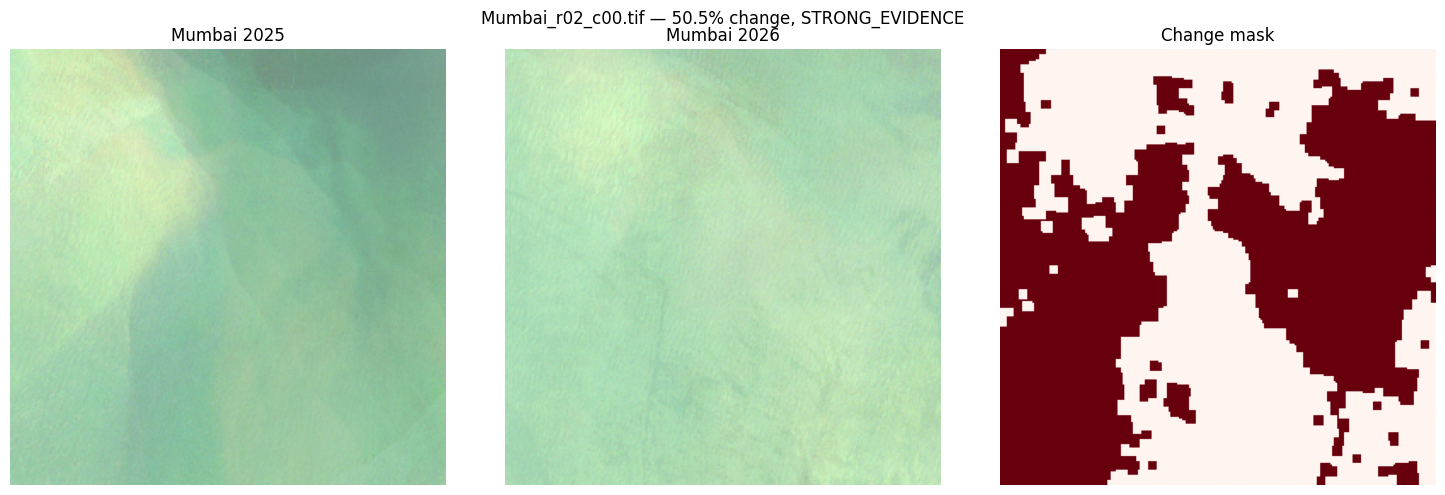

In [18]:
import matplotlib.pyplot as plt

top = change_df.sort_values("change_percent", ascending=False).iloc[0]
print(f"Top change: {top.city} / {top.tile} ({int(top.year_from)} vs {int(top.year_to)}) "
      f"— {top.change_percent:.2f}% changed, evidence={top.evidence_level}")

result = process_image_pair(top.city, top.tile, int(top.year_from), int(top.year_to))

def rgb_preview(arr):
    # bands are B02,B03,B04,... -> true colour needs B04,B03,B02 = idx 2,1,0
    rgb = np.dstack((arr[2], arr[1], arr[0])).astype(np.float32)
    rgb = rgb / (rgb.max() + 1e-6)
    return np.clip(rgb, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb_preview(result["before"])); axes[0].set_title(f"{top.city} {int(top.year_from)}"); axes[0].axis("off")
axes[1].imshow(rgb_preview(result["after"])); axes[1].set_title(f"{top.city} {int(top.year_to)}"); axes[1].axis("off")
axes[2].imshow(result["mask"], cmap="Reds"); axes[2].set_title("Change mask"); axes[2].axis("off")
fig.suptitle(f"{top.tile} — {top.change_percent:.1f}% change, {top.evidence_level}")
fig.tight_layout()
plt.show()

## Step 12 — Export one result as JSON (for the backend team)

This is the shape Member 4 can plug into `/api/change/{tile_id}` or similar.

In [19]:
import json

def row_to_json(row):
    return json.dumps({
        "city": row["city"], "tile_id": row["tile_id"],
        "year_from": int(row["year_from"]), "year_to": int(row["year_to"]),
        "change_percent": round(float(row["change_percent"]), 2),
        "mean_change": round(float(row["mean_change"]), 3),
        "num_components": int(row["num_components"]),
        "largest_component_percent": round(float(row["largest_component_percent"]), 2),
        "false_alarm_class": row["false_alarm_class"],
        "false_alarm_reason": row["false_alarm_reason"],
        "spatial_status": row["spatial_status"],
        "persistence_status": row["persistence_status"],
        "supported_change_intervals": int(row["supported_change_intervals"]),
        "evidence_level": row["evidence_level"],
        "confidence_score": float(row["confidence_score"]),
        "change_category": row["change_category"],
        "lat": None if pd.isna(row["lat_c"]) else float(row["lat_c"]),
        "lon": None if pd.isna(row["lon_c"]) else float(row["lon_c"]),
        "change_mask_path": row["mask_path"],
    }, indent=2)

print(row_to_json(top))

{
  "city": "Mumbai",
  "tile_id": "Mumbai_r02_c00",
  "year_from": 2025,
  "year_to": 2026,
  "change_percent": 50.47,
  "mean_change": 0.297,
  "num_components": 19,
  "largest_component_percent": 24.62,
  "false_alarm_class": "STRUCTURED_CHANGE",
  "false_alarm_reason": "NONE_DETECTED",
  "spatial_status": "SPATIALLY_CONNECTED",
  "persistence_status": "PERSISTENT_CHANGE_SIGNAL",
  "supported_change_intervals": 6,
  "evidence_level": "STRONG_EVIDENCE",
  "confidence_score": 0.948,
  "change_category": "UNKNOWN",
  "lat": 19.109689201412664,
  "lon": 72.79213821708883,
  "change_mask_path": "/content/drive/MyDrive/satellite_change_detection/masks/Mumbai/Mumbai_r02_c00_2025_2026.png"
}
